# 0. Introduction
The goal of this notebook is to slowly build up to having full AGN simulation using agnSED and perturbations to account for the time domain.

# 1. Thin disk model
We will start by implementing a thin disk model with the gaussian random field perturbation s only. To simplify the code, we will start by building them without Caskade and without JAX. 

In [2]:
import os
from warnings import filters
import jax.numpy as jnp
import jax
from caskade import Param, forward
import numpy as np
from cosmographi.cosmology import Cosmology
from cosmographi.source import TransientSource
from cosmographi.utils import flux
from cosmographi.utils.constants import Mpc_to_cm, G, sigma, h_m2kg, k_m2kgsminus2
from typing import Any
from cosmographi.utils.constants import c_m
from scipy.integrate import quad
from numpy import pi


2026-06-18 16:31:03.978067: W external/xla/xla/service/gpu/nvptx_compiler.cc:760] The NVIDIA driver's CUDA version is 12.2 which is older than the ptxas CUDA version (12.9.86). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [6]:
from cosmographi.cosmology import Cosmology
from cosmographi.source.agn import AGNSourceThinDisk
C = Cosmology()
M_sun = 10e8
agn = AGNSourceThinDisk(name="agn1", cosmology = C, blackhole_mass=10e8*M_sun, accretion_rate=M_sun, r_star=1.5e11, inclination_angle=0) 

# agn.blackhole_mass = 10**7
# agn.accretion_rate = 10**(-2)
agn.luminosity_density(w=10e-8, z=0.01)

TypeError: AGNSourceThinDisk.luminosity_density() got an unexpected keyword argument 'z'

In [17]:
pi = np.pi
G = 6.6743 * 10e-11  # m3⋅kg−1⋅s−2
sigma =  5.670374419 * 10e-8 #  Stephan-Boltzman constant (sigma) = 5.670374419 × 10⁻⁸ W⋅m⁻²⋅K⁻
h = 6.62607015 * 10e-34 #m2 kg / s planck's constant
k = 1.380649 * 10e-23 # m2 kg s-2 K-1  boltzman constant
M_sun = 1.98847e30      # kg
# we assume R∗​=RISCO​=6GM​/c**2

def temp(R: float, mass: float, acc_rate: float, r_star: float) -> float:
    """ Return the temperature at distance <R> for an AGN of <mass> and accretion rate <acc_rate>"""
    first_prod = 3 * G * mass * acc_rate / 8 /pi / R**3 / sigma
    second_prod = 1 - (r_star / R) ** (1/2)
    return (first_prod * second_prod) ** (1/4)

def _integrand_funct(R: float, freq: float, mass: float, acc_rate: float, r_star: float) -> float:
    return R / (np.exp(h*freq/k/temp(R, mass, acc_rate, r_star)) - 1)

def flux_density(freq: float, inclination_angle: float, mass: float, acc_rate: float, r_star: float, luminosity_distance: float) -> float:
    """ Calculate the flux density at a specific frecuency for a specific agn"""
    first_prod = 4*pi*h*np.cos(inclination_angle)*freq**3/c_m**2 / luminosity_distance**2
    # assume R_out is 10**4 * r_star
    second_prod = quad(_integrand_funct, r_star, 10**4 * r_star, args=(freq,mass,acc_rate,r_star))[0]
    return first_prod * second_prod 


In [ ]:
flux_density(c_m/(500e-9), 0, 10e8*M_sun, M_sun, 1.5e11, 0.01)

np.float64(1.3000992035147705e+31)

In [ ]:

def temp(R: float, mass: float, acc_rate: float, r_star: float) -> float:
    """ Return the temperature at distance <R> for an AGN of <mass> and accretion rate <acc_rate>"""
    first_prod = 3 * G * mass * acc_rate / 8 /pi / R**3 / sigma
    second_prod = 1 - (r_star / R) ** (1/2)
    return (first_prod * second_prod) ** (1/4)

class AGNSourceThinDisk(TransientSource):
    """ create an AGN source whose SED is modelled according to the thin disk model

    Parameters
    ---------- 
    cosmology: Cosmology. 
        Optional. If given, it can be used to compute the distance modulus from the redshift.
    name: str. 
        Optional. Name of the source.
    blackhole_mass: float. 
        Mass of the black hole in solar masses 
    accretion_rate: float. 
        Accretion rate of the black hole 
    """
    name: str
    cosmology: Cosmology
    blackhole_mass: float
    accretion_rate: float
    inclination_angle: float

    def __init__(self, cosmology: Cosmology = None, name: str = None, blackhole_mass: float = None, 
                 accretion_rate: float = None,inclination_angle: float = None, r_star: float = None, **kwargs) -> None:
        super().__init__(cosmology=cosmology, name=name, **kwargs)
        # self.blackhole_mass = Param("blackhole_mass", blackhole_mass, shape=(), 
        #                            description="Mass of the black hole", units="solar masses")
        # self.accretion_rate = Param("accretion_rate", accretion_rate, shape=(), 
        #                            description="accretion_rate of the black hole", units="dimensionless")  
        self.blackhole_mass = blackhole_mass
        self.accretion_rate = accretion_rate
        self.inclination_angle = inclination_angle
        self.r_star = r_star

    def flux_density(self, freq: float, luminosity_distance: float) -> float:
        """ Calculate the flux at a specific frecuency for a specific agn"""
        inclination_angle, mass, acc_rate, r_star = self.inclination_angle, self.blackhole_mass, self.accretion_rate, self.r_star
        pi = np.pi
        G = 6.6743 * 10e-11  # m3⋅kg−1⋅s−2
        sigma =  5.670374419 * 10e-8 #  Stephan-Boltzman constant (sigma) = 5.670374419 × 10⁻⁸ W⋅m⁻²⋅K⁻
        h = 6.62607015 * 10e-34 #m2 kg / s planck's constant
        k = 1.380649 * 10e-23 # m2 kg s-2 K-1  boltzman constant
        M_sun = 1.98847e30      # kg
        # we assume R∗​=RISCO​=6GM​/c**2
        first_prod = 4*pi*h*np.cos(inclination_angle)*freq**3/c_m**2 / luminosity_distance**2
        # assume R_out is 10**4 * r_star
        second_prod = quad(_integrand_funct, r_star, 10**4 * r_star, args=(freq,mass,acc_rate,r_star))[0]
        return first_prod * second_prod 
        

    def luminosity_density(self, w: float, z: float) -> float:
        """ Return the luminosity density between wavelengths <start> and <end> and at redshift <z>.
        #TODO include time 
        <w> is the wavelength IN METRES
        """
        # transforming the wavelengths to at-observer wavelengths (accounting for redshift)
        w_rest = w/(z + 1)
        freq_rest = c_m/w_rest
        distance_parsec = 10 # for standard
        luminosity_distance = distance_parsec * 3.086e+16
        flux = self.flux_density(freq_rest, luminosity_distance)
        luminosity_density = flux * 4 * jnp.pi * luminosity_distance **2
        return luminosity_density
        

In [ ]:
from cosmographi.cosmology import Cosmology
C = Cosmology()
agn = AGNSourceThinDisk(name="agn1", cosmology = C, blackhole_mass=10e8*M_sun, accretion_rate=M_sun, r_star=1.5e11, inclination_angle=0) 
# agn.blackhole_mass = 10**7
# agn.accretion_rate = 10**(-2)
agn.luminosity_density(10e-8, 0.01)

np.float64(2.9760603340936724e+29)

# 2. Caskading it
Now that the class works like that, I will be working on making it compatible with Caskade

In [ ]:

def temp(R: float, mass: float, acc_rate: float, r_star: float) -> float:
    """ Return the temperature at distance <R> for an AGN of <mass> and accretion rate <acc_rate>"""
    first_prod = 3 * G * mass * acc_rate / 8 /pi / R**3 / sigma
    second_prod = 1 - (r_star / R) ** (1/2)
    return (first_prod * second_prod) ** (1/4)

class AGNSourceThinDisk(TransientSource):
    """ create an AGN source whose SED is modelled according to the thin disk model

    Parameters
    ---------- 
    cosmology: Cosmology. 
        Optional. If given, it can be used to compute the distance modulus from the redshift.
    name: str. 
        Optional. Name of the source.
    blackhole_mass: float. 
        Mass of the black hole in solar masses 
    accretion_rate: float. 
        Accretion rate of the black hole 
    """
    name: str
    cosmology: Cosmology
    blackhole_mass: Param
    accretion_rate: Param
    inclination_angle: Param
    r_star: Param

    def __init__(self, cosmology: Cosmology = None, name: str = None, blackhole_mass: float = None, 
                 accretion_rate: float = None,inclination_angle: float = None, r_star: float = None, **kwargs) -> None:
        super().__init__(cosmology=cosmology, name=name, **kwargs)
        self.blackhole_mass = Param("blackhole_mass", blackhole_mass, shape=(), 
                                   description="Mass of the black hole", units="solar masses")
        self.accretion_rate = Param("accretion_rate", accretion_rate, shape=(), 
                                   description="accretion_rate of the black hole", units="dimensionless")
        self.inclination_angle = Param("inclination_angle", inclination_angle, units="radians", description="inclination angle of the AGN with respect to the observer")
        self.r_star = Param("r_sar", r_star, units="metres", description="inner radius of the thin disk, smallest radius from which heat radiates")
    
    
    @forward
    def flux_density(self, freq: float, luminosity_distance: float, inclination_angle=None, blackhole_mass=None, accretion_rate=None, r_star=None) -> float:
        """ Calculate the flux at a specific frecuency for a specific agn"""
        # inclination_angle, mass, acc_rate, r_star = self.inclination_angle, self.blackhole_mass, self.accretion_rate, self.r_star
        pi = np.pi
        G = 6.6743 * 10e-11  # m3⋅kg−1⋅s−2
        sigma =  5.670374419 * 10e-8 #  Stephan-Boltzman constant (sigma) = 5.670374419 × 10⁻⁸ W⋅m⁻²⋅K⁻
        h = 6.62607015 * 10e-34 #m2 kg / s planck's constant
        k = 1.380649 * 10e-23 # m2 kg s-2 K-1  boltzman constant
        M_sun = 1.98847e30      # kg
        # we assume R∗​=RISCO​=6GM​/c**2
        first_prod = 4*pi*h*np.cos(inclination_angle)*freq**3/c_m**2 / luminosity_distance**2
        # assume R_out is 10**4 * r_star
        second_prod = quad(_integrand_funct, r_star, 10**4 * r_star, args=(freq,blackhole_mass,accretion_rate,r_star))[0]
        return first_prod * second_prod 
        
    def luminosity_density(self, w: float, z: float) -> float:
        """ Return the luminosity density between wavelengths <start> and <end> and at redshift <z>.
        #TODO include time 
        <w> is the wavelength IN METRES
        """
        # transforming the wavelengths to at-observer wavelengths (accounting for redshift)
        w_rest = w/(z + 1)
        freq_rest = c_m/w_rest
        distance_parsec = 10 # for standard
        luminosity_distance = distance_parsec * 3.086e+16
        flux = self.flux_density(freq=freq_rest, luminosity_distance=luminosity_distance)
        luminosity_density = flux * 4 * jnp.pi * luminosity_distance **2
        return luminosity_density

In [ ]:
from cosmographi.cosmology import Cosmology
C = Cosmology()
agn = AGNSourceThinDisk(name="agn1", cosmology = C, blackhole_mass=10e8*M_sun, accretion_rate=M_sun, r_star=1.5e11, inclination_angle=0) 

# agn.blackhole_mass = 10**7
# agn.accretion_rate = 10**(-2)
agn.luminosity_density(w=10e-8, z=0.01)

np.float64(2.9760603340936724e+29)

# 3. Including variation in the time domain
THis will be done using Gaussian random fields.

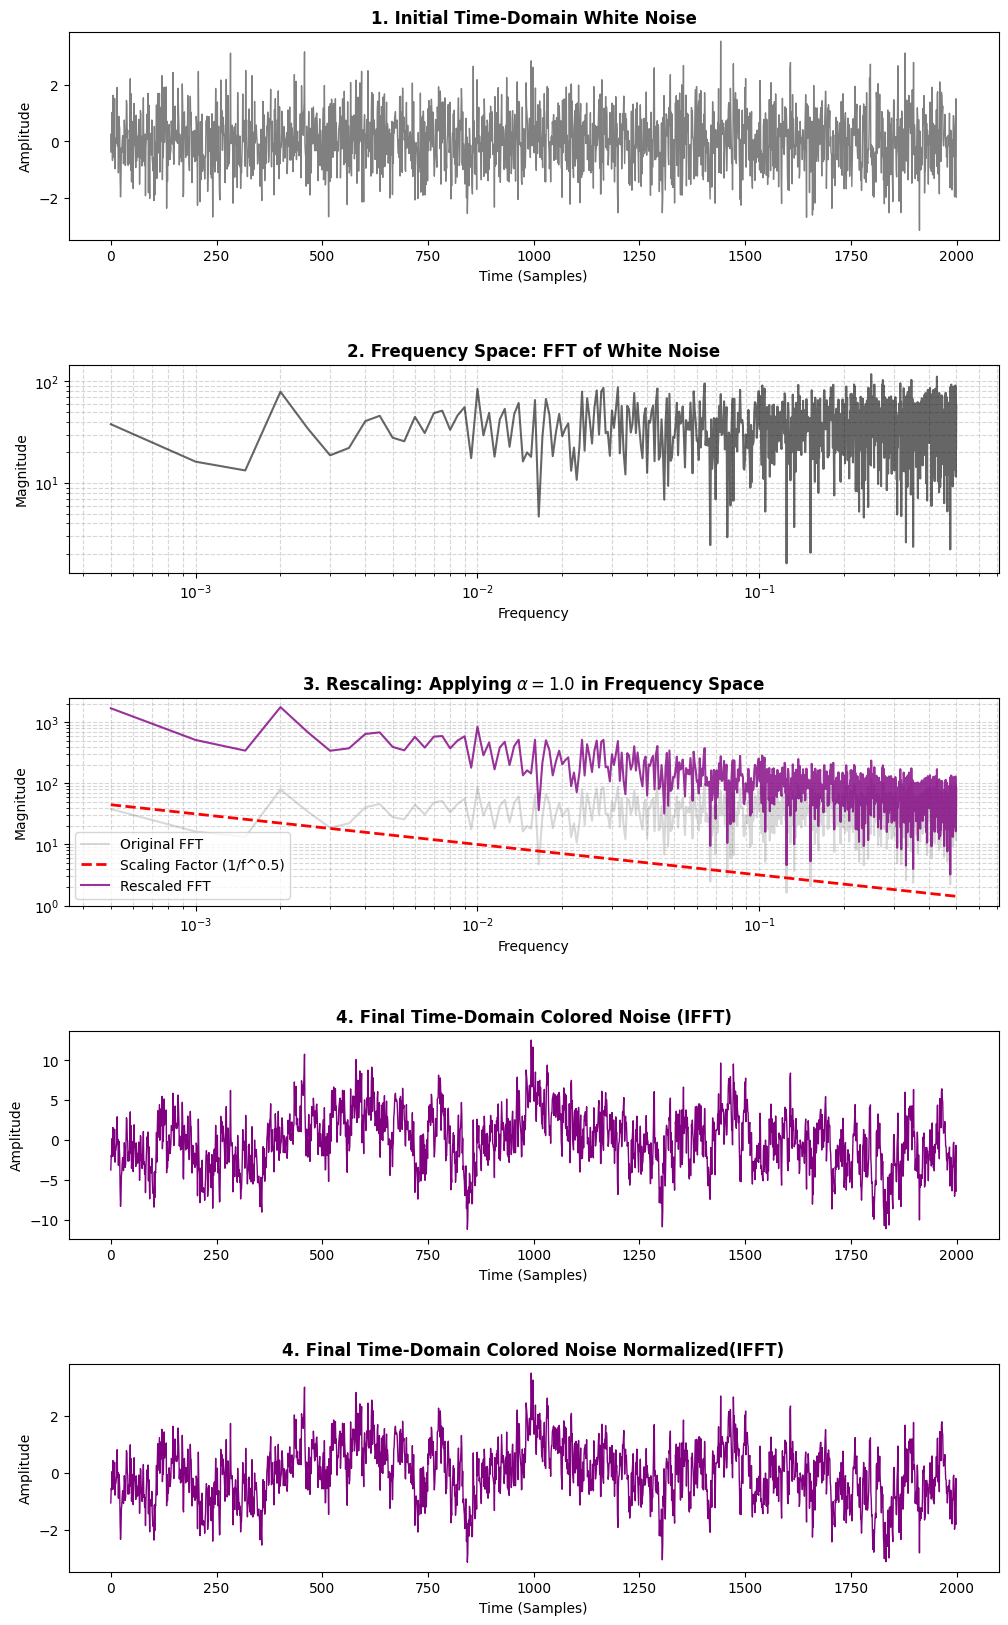

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def generate_and_plot_colored_noise(alpha, n_samples=1000, sample_rate=1.0):
    """
    Generates 1D colored noise and plots the transformation steps.

    Parameters:
    alpha (float): The frequency scaling parameter (0=white, 1=pink, 2=brown).
    n_samples (int): Number of data points to generate.
    sample_rate (float): Assumed sample rate for frequency calculation.
    """

    # ---------------------------------------------------------
    # Step 1: Generate initial white noise
    # ---------------------------------------------------------
    white_noise = np.random.normal(0, 1, n_samples)

    # ---------------------------------------------------------
    # Step 2: Compute FFT (Real FFT since signal is real)
    # ---------------------------------------------------------
    fft_white = np.fft.rfft(white_noise)
    frequencies = np.fft.rfftfreq(n_samples, d=1/sample_rate)

    # ---------------------------------------------------------
    # Step 3: Rescaling in frequency space
    # ---------------------------------------------------------
    # Ignore divide by zero for the DC component (f=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        # Amplitude scales as 1/f^(alpha/2)
        scaling_factor = 1.0 / (frequencies ** (alpha / 2.0))

    # Set the DC component (0 Hz) to 0 to avoid infinite values and mean offsets
    scaling_factor[0] = 0.0

    # Apply the frequency scaling to the white noise FFT
    fft_colored = fft_white * scaling_factor

    # ---------------------------------------------------------
    # Step 4: Compute IFFT to get back to the time domain
    # ---------------------------------------------------------
    colored_noise = np.fft.irfft(fft_colored, n=n_samples)

    # Normalize the final signal to have a standard deviation of 1 for easy viewing
    colored_noise_normalized = colored_noise / np.std(colored_noise)


    # ---------------------------------------------------------
    # Plotting the Steps
    # ---------------------------------------------------------
    fig, axes = plt.subplots(5, 1, figsize=(12, 20))
    fig.subplots_adjust(hspace=0.6)

    # 1. Initial White Noise
    axes[0].plot(white_noise, color='gray', linewidth=1)
    axes[0].set_title("1. Initial Time-Domain White Noise", fontweight='bold')
    axes[0].set_xlabel("Time (Samples)")
    axes[0].set_ylabel("Amplitude")

    # 2. FFT of White Noise
    # Slicing from 1: to ignore the DC component for log-log plotting
    axes[1].loglog(frequencies[1:], np.abs(fft_white)[1:], color='black', alpha=0.6)
    axes[1].set_title("2. Frequency Space: FFT of White Noise", fontweight='bold')
    axes[1].set_xlabel("Frequency")
    axes[1].set_ylabel("Magnitude")
    axes[1].grid(True, which="both", ls="--", alpha=0.5)

    # 3. Rescaling in Frequency Space
    axes[2].loglog(frequencies[1:], np.abs(fft_white)[1:], color='gray', alpha=0.3, label='Original FFT')
    axes[2].loglog(frequencies[1:], scaling_factor[1:], color='red', linestyle='--', linewidth=2, label=f'Scaling Factor (1/f^{alpha/2})')
    axes[2].loglog(frequencies[1:], np.abs(fft_colored)[1:], color='purple', alpha=0.8, label='Rescaled FFT')
    axes[2].set_title(f"3. Rescaling: Applying $\\alpha={alpha}$ in Frequency Space", fontweight='bold')
    axes[2].set_xlabel("Frequency")
    axes[2].set_ylabel("Magnitude")
    axes[2].legend()
    axes[2].grid(True, which="both", ls="--", alpha=0.5)

    # 4. Final Colored Noise (IFFT)
    axes[3].plot(colored_noise, color='purple', linewidth=1)
    axes[3].set_title(f"4. Final Time-Domain Colored Noise (IFFT)", fontweight='bold')
    axes[3].set_xlabel("Time (Samples)")
    axes[3].set_ylabel("Amplitude")


     # 4. Final Colored Noise (IFFT)
    axes[4].plot(colored_noise_normalized, color='purple', linewidth=1)
    axes[4].set_title(f"4. Final Time-Domain Colored Noise Normalized(IFFT)", fontweight='bold')
    axes[4].set_xlabel("Time (Samples)")
    axes[4].set_ylabel("Amplitude")
    plt.show()
# Run the function (Try changing alpha to 1.0 for Pink or 2.0 for Brown)
if __name__ == "__main__":
    generate_and_plot_colored_noise(alpha=1.0, n_samples=2000)

The way I am planning of incorporating it is to have a function where one "loads" the model. Here, the user will specify the timeframe and wavelength-frame (?) it will want to query, as well as the grid resolution, i.e. a sample per hom much time or wavelength difference. This function will do the heavy lifting and calculate a grid. After this, the user can simply query any point of the covered wavelength and time frame, and we will return an interpolation over the calculated points. 

In [ ]:
#TODO: look into different interpolation methods, uniform vs non-uniform grid calculating, "calibrating" noise so it looks like an AGN, etc. 
# TODO: for now we will sample noise once per daym, but we could consider changing this too!

In [33]:

import jax.numpy as jnp
from math import ceil, floor
# redifine class to add methods
def temp(R: float, mass: float, acc_rate: float, r_star: float) -> float:
    """ Return the temperature at distance <R> for an AGN of <mass> and accretion rate <acc_rate>"""
    first_prod = 3 * G * mass * acc_rate / 8 /pi / R**3 / sigma
    second_prod = 1 - (r_star / R) ** (1/2)
    return (first_prod * second_prod) ** (1/4)

def _integrand_funct(R: float, freq: float, mass: float, acc_rate: float, r_star: float) -> float:
    return R / (np.exp(h_m2kg*freq/k_m2kgsminus2/temp(R, mass, acc_rate, r_star)) - 1)

def GridNotComputedError(Exception):
    print("The model was not applied correctly. Please compute the grid correctly using the load_luminosity function.")



#TODO: Rewrite it!
def generate_random_field(alpha, n_samples, sample_rate=1.0):
    """
    Generates 1D colored noise and plots the transformation steps.

    Parameters:
    alpha (float): The frequency scaling parameter (0=white, 1=pink, 2=brown).
    n_samples (int): Number of data points to generate.
    sample_rate (float): Assumed sample rate for frequency calculation.
    """
    white_noise = np.random.normal(0, 1, n_samples)
    fft_white = np.fft.rfft(white_noise)
    frequencies = np.fft.rfftfreq(n_samples, d=1/sample_rate)
    # Ignore divide by zero for the DC component (f=0)
    with np.errstate(divide='ignore', invalid='ignore'):
        # Amplitude scales as 1/f^(alpha/2)
        scaling_factor = 1.0 / (frequencies ** (alpha / 2.0))
    scaling_factor[0] = 0.0
    fft_colored = fft_white * scaling_factor
    colored_noise = np.fft.irfft(fft_colored, n=n_samples)
    return colored_noise


class AGNSourceThinDisk(TransientSource):
    """ create an AGN source whose SED is modelled according to the thin disk model

    Parameters
    ---------- 
    cosmology: Cosmology. 
        Optional. If given, it can be used to compute the distance modulus from the redshift.
    name: str. 
        Optional. Name of the source.
    blackhole_mass: float. 
        Mass of the black hole in solar masses 
    accretion_rate: float. 
        Accretion rate of the black hole 
    inclination_angle: Param(float)
        Inclination angle of the AGN with respect to the observer. The oberver's line of sight makes an angle i 
        to the normal to the disc plane. In radians. 
    r_star: Param(float)
        inner radius of the thin disk, smallest radius from which heat radiates. We assume it to be the innermost 
        stable circular orbit (ISCO), since we assume a non-rotating black hole.
    grid: jnp.ndarray | None
        An array containing the calculated values for the luminosity grid. COmputed during load_luminosity. 
    grid_w_chars: tuple[float] | None
        A tuple containing, in that order, the start wavelength, end wavelength, and wavelength in between sampling from self.grid
    grid_t_chars: tuple[float] | None
        A tuple containing, in that order, the start time, end time, and time in between sampling from self.grid
    """
    name: str
    cosmology: Cosmology
    blackhole_mass: Param
    accretion_rate: Param
    inclination_angle: Param
    r_star: Param
    grid: jnp.ndarray | None 
    grid_w_chars: tuple[float] | None
    grid_t_chars: tuple[float] | None

    def __init__(self, cosmology: Cosmology = None, name: str = None, blackhole_mass: float = None, 
                 accretion_rate: float = None,inclination_angle: float = None, r_star: float = None, **kwargs) -> None:
        super().__init__(cosmology=cosmology, name=name, **kwargs)
        self.blackhole_mass = Param("blackhole_mass", blackhole_mass, shape=(), 
                                   description="Mass of the black hole", units="solar masses")
        self.accretion_rate = Param("accretion_rate", accretion_rate, shape=(), 
                                   description="accretion_rate of the black hole", units="dimensionless")
        self.inclination_angle = Param("inclination_angle", inclination_angle, units="radians", description="inclination angle of the AGN with respect to the observer")
        self.r_star = Param("r_sar", r_star, units="metres", description="inner radius of the thin disk, smallest radius from which heat radiates")
        self.grid = None
    
    @forward
    def flux_density(self, freq: float, luminosity_distance: float, inclination_angle=None, blackhole_mass=None, accretion_rate=None, r_star=None) -> float:
        """ Calculate the flux at a specific frecuency for a specific agn"""
        # inclination_angle, mass, acc_rate, r_star = self.inclination_angle, self.blackhole_mass, self.accretion_rate, self.r_star
        pi = np.pi
        G = 6.6743 * 10e-11  # m3⋅kg−1⋅s−2
        sigma =  5.670374419 * 10e-8 #  Stephan-Boltzman constant (sigma) = 5.670374419 × 10⁻⁸ W⋅m⁻²⋅K⁻
        h = 6.62607015 * 10e-34 #m2 kg / s planck's constant
        k = 1.380649 * 10e-23 # m2 kg s-2 K-1  boltzman constant
        M_sun = 1.98847e30      # kg
        # we assume R∗​=RISCO​=6GM​/c**2
        first_prod = 4*pi*h*np.cos(inclination_angle)*freq**3/c_m**2 / luminosity_distance**2
        # assume R_out is 10**4 * r_star
        second_prod = quad(_integrand_funct, r_star, 10**4 * r_star, args=(freq,blackhole_mass,accretion_rate,r_star))[0]
        return first_prod * second_prod 
        
    def get_expensive_luminosity_density(self, w: float) -> float:
        """ Return the luminosity density between wavelengths <start> and <end> and at redshift <z>.
        #TODO include time 
        <w> is the wavelength IN METRES of the rest frame
        """
        freq_rest = c_m/w
        distance_parsec = 10 # for standard
        luminosity_distance = distance_parsec * 3.086e+16
        flux = self.flux_density(freq=freq_rest, luminosity_distance=luminosity_distance)
        luminosity_density = flux * 4 * jnp.pi * luminosity_distance **2
        return luminosity_density


    def load_luminosity(self, start_time: float, end_time: float, start_w: float, end_w: float, time_res: float, w_res: float) -> None:
        """Create the grid we will then interpolate from, between <start_time> and <end_time>, with a time sample 
        every <time_res> and between <start_w> and <end_w>, with a sample every <w_res>. the resulting grid is stored 
        in self.grid as a jnp.ndarray
        same collumn = same wavelength, same row = same time

        TImes are in MJD and wavelengths in metres.

        """
        self.grid_w_chars = (start_w, end_w, w_res)
        self.grid_t_chars = (start_time, end_time, time_res)
        noise = generate_random_field(1.0, int(abs(start_time - end_time)/ time_res) + 1, time_res)
        rows = []
        for time in range(int(abs(start_time - end_time)/ time_res) + 1):
            row = []
            for w in jnp.arange(start_w, end_w + w_res, w_res):
                row.append(self.get_expensive_luminosity_density(w) + noise[time])
            rows.append(row)
        self.grid = jnp.asarray(rows)
       
    
    def luminosity_density(self, wavelengths: jnp.ndarray, times: jnp.ndarray) -> jnp.ndarray:
        """Approximate the luminosity at time <t> (MJD) and wavelength <w> (in metres). The approximation is done by taking an 
        average of the four points that result from rounding up and down both w and t.

        same collumn = same wavelength, same row = same time

        """
        rows = []
        for t in times:
            row = []
            for w in wavelengths:
                if self.grid is None or self.grid_w_chars is None or self.grid_t_chars is None:
                    raise GridNotComputedError
                if not (self.grid_t_chars[0] <= t <=self.grid_t_chars[1]):
                    raise ValueError("Queryied time must be in between the minimum and maximum times passed when loading the model")
                if not (self.grid_w_chars[0] <= w <=self.grid_w_chars[1]):
                    raise ValueError("Queryied wavelength must be in between the minimum and maximum wavelengths passed when loading the model")
                row_upper = ceil((t - self.grid_t_chars[0])/self.grid_t_chars[2])
                row_lower = floor((t - self.grid_t_chars[0])/self.grid_t_chars[2])
                col_upper = ceil((w - self.grid_w_chars[0])/self.grid_w_chars[2])
                col_lower = floor((w - self.grid_w_chars[0])/self.grid_w_chars[2])

                print(f"row_upper={row_upper}", f"row_lower = {row_lower}", f"col_upper={col_upper}", f"col_lower={col_lower}")

                row.append((self.grid[row_upper][col_upper] + self.grid[row_upper][col_lower] + self.grid[row_lower][col_upper] + 
                        self.grid[row_lower][col_lower])/4)
            rows.append(row)
        return jnp.asarray(rows)
    

In [35]:
agn = AGNSourceThinDisk(name="agn1", blackhole_mass=10e8*M_sun, accretion_rate=M_sun, r_star=1.5e11, inclination_angle=0) 
agn.load_luminosity(start_time=6500, end_time=6520, start_w=1, end_w=3, time_res=4, w_res=0.5)
print(agn.grid)
print(agn.luminosity_density(jnp.asarray([2.0]), jnp.asarray([6510.0])))
print(agn.luminosity_density(jnp.asarray([2.0, 2.5]), jnp.asarray([6510.0, 6515.0])))

/tmp/ipykernel_2382513/295318373.py:11: RuntimeWarning: overflow encountered in exp
  return R / (np.exp(h_m2kg*freq/k_m2kgsminus2/temp(R, mass, acc_rate, r_star)) - 1)


[[-1.17119762 -1.169869   -1.16590818 -1.16016751 -1.15401934]
 [ 0.44821667  0.44954528  0.4535061   0.45924678  0.46539495]
 [ 0.24544526  0.24677388  0.25073469  0.25647537  0.26262354]
 [ 0.86185988  0.8631885   0.86714931  0.87288999  0.87903816]
 [ 0.11210104  0.11342966  0.11739047  0.12313115  0.12927932]
 [-0.4960016  -0.49467298 -0.49071216 -0.48497149 -0.47882332]]
row_upper=3 row_lower = 2 col_upper=2 col_lower=2
[[0.558942]]
row_upper=3 row_lower = 2 col_upper=2 col_lower=2
row_upper=3 row_lower = 2 col_upper=3 col_lower=3
row_upper=4 row_lower = 3 col_upper=2 col_lower=2
row_upper=4 row_lower = 3 col_upper=3 col_lower=3
[[0.558942   0.56468268]
 [0.49226989 0.49801057]]


In [ ]:
# TODO: The handling of start - end not being a multiple of the resolution may not be being handled
# TODO: Not handling correctly when one fo the queryed time/ wavelengths is represented in the grid

In [3]:
from cosmographi.source.agn import AGNSourceThinDisk
M_sun = 10e8
agn = AGNSourceThinDisk(name="agn1", blackhole_mass=10e8*M_sun, accretion_rate=M_sun, r_star=1.5e11, inclination_angle=0) 
agn.load_luminosity(start_time=6500, end_time=6520, start_w=1, end_w=3, time_res=4, w_res=0.5)
print(agn.grid)
print(agn.luminosity_density(jnp.asarray([2.0]), jnp.asarray([6510.0])))
print(agn.luminosity_density(jnp.asarray([2.0, 2.5]), jnp.asarray([6510.0, 6515.0])))

AttributeError: 'AGNSourceThinDisk' object has no attribute 'load_luminosity'